# 🗳️ Voting & Stacking

Bagging combines many copies of the **same** algorithm; boosting builds a sequence of the **same** weak learner type. Voting and Stacking do something different: combine **genuinely different** algorithm families — Logistic Regression, KNN, a tree, an SVM — into one ensemble, betting that their different mistakes will cancel out.

📖 Full mathematical explanation (hard vs soft voting, why diversity matters, stacking's meta-learner formulation): [README.md](README.md)


## 1. Setup & Dataset


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(42)

cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")


Train: (455, 30), Test: (114, 30)


## 2. Individual Base Models — the Building Blocks

Four genuinely different algorithms, each already covered in depth in the Classification category, as the ensemble's raw material.


In [2]:
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Naive Bayes": GaussianNB(),
}

for name, model in base_models.items():
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    print(f"{name:22s} -> test accuracy: {acc:.4f}")


Logistic Regression    -> test accuracy: 0.9825


KNN (k=7)              -> test accuracy: 0.9737
Decision Tree          -> test accuracy: 0.9386
Naive Bayes            -> test accuracy: 0.9298


## 3. Hard Voting — Majority Vote on Hard Labels

Every base model predicts a class label; the ensemble predicts whichever label the majority agreed on. Simple, and requires no calibrated probabilities from any base model.


In [3]:
hard_voter = VotingClassifier(
    estimators=[(name, model) for name, model in base_models.items()],
    voting="hard"
)
hard_voter.fit(X_train_s, y_train)
hard_preds = hard_voter.predict(X_test_s)
print(f"Hard Voting test accuracy: {accuracy_score(y_test, hard_preds):.4f}")


Hard Voting test accuracy: 0.9649


## 4. Soft Voting — Averaging Predicted Probabilities

Instead of each model casting one vote, soft voting averages every model's `predict_proba()` output, then thresholds the average. This uses more information per model (confidence, not just a hard label) and often edges out hard voting.


In [4]:
soft_voter = VotingClassifier(
    estimators=[(name, model) for name, model in base_models.items()],
    voting="soft"
)
soft_voter.fit(X_train_s, y_train)
soft_preds = soft_voter.predict(X_test_s)
print(f"Soft Voting test accuracy: {accuracy_score(y_test, soft_preds):.4f}")

# Inspect what soft voting actually averages, for one test point
sample = X_test_s[:1]
for name, model in soft_voter.named_estimators_.items():
    print(f"  {name:22s} P(malignant)={model.predict_proba(sample)[0,0]:.3f}, P(benign)={model.predict_proba(sample)[0,1]:.3f}")
avg_proba = soft_voter.predict_proba(sample)[0]
print(f"  {'AVERAGED':22s} P(malignant)={avg_proba[0]:.3f}, P(benign)={avg_proba[1]:.3f}")


Soft Voting test accuracy: 0.9649
  Logistic Regression    P(malignant)=1.000, P(benign)=0.000
  KNN (k=7)              P(malignant)=1.000, P(benign)=0.000
  Decision Tree          P(malignant)=1.000, P(benign)=0.000
  Naive Bayes            P(malignant)=1.000, P(benign)=0.000
  AVERAGED               P(malignant)=1.000, P(benign)=0.000


## 5. Why Diversity Matters — Correlated vs Diverse Errors

Voting only helps when base models make **different** mistakes. If every base model gets the exact same points wrong, averaging changes nothing. We verify this directly by measuring how correlated each pair of base models' errors actually is.


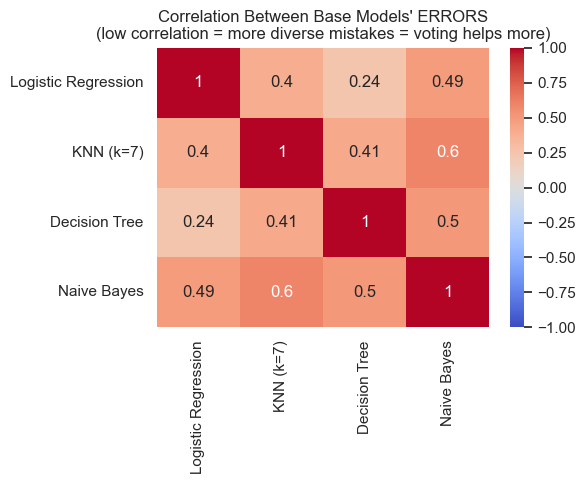

In [5]:
error_matrix = pd.DataFrame({
    name: (model.predict(X_test_s) != y_test).astype(int).values
    for name, model in base_models.items()
})

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(error_matrix.corr(), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Between Base Models' ERRORS\n(low correlation = more diverse mistakes = voting helps more)")
plt.tight_layout()
plt.show()


## 6. Voting with Correlated Base Models — a Controlled Failure Case

Deliberately voting among near-identical models (several KNN variants with very similar $k$) should show little to no improvement over any single one — a direct, controlled demonstration of section 5's point, not just a claim.


In [6]:
similar_models = {
    "KNN k=5": KNeighborsClassifier(n_neighbors=5),
    "KNN k=6": KNeighborsClassifier(n_neighbors=6),
    "KNN k=7": KNeighborsClassifier(n_neighbors=7),
    "KNN k=8": KNeighborsClassifier(n_neighbors=8),
}
for m in similar_models.values():
    m.fit(X_train_s, y_train)

similar_voter = VotingClassifier(estimators=[(n, m) for n, m in similar_models.items()], voting="soft")
similar_voter.fit(X_train_s, y_train)

individual_accs = [accuracy_score(y_test, m.predict(X_test_s)) for m in similar_models.values()]
voted_acc = accuracy_score(y_test, similar_voter.predict(X_test_s))

print(f"Individual KNN accuracies (k=5..8): {[round(a, 4) for a in individual_accs]}")
print(f"Voted ensemble accuracy:            {voted_acc:.4f}")
print("\n-> Barely different from the individual models -- these 4 KNN variants make highly")
print("   correlated errors (they're all 'the same idea' with a minor parameter tweak), so voting")
print("   has little diverse signal to combine. Compare this to section 4's genuinely diverse ensemble.")


Individual KNN accuracies (k=5..8): [0.9561, 0.9561, 0.9737, 0.9737]
Voted ensemble accuracy:            0.9737

-> Barely different from the individual models -- these 4 KNN variants make highly
   correlated errors (they're all 'the same idea' with a minor parameter tweak), so voting
   has little diverse signal to combine. Compare this to section 4's genuinely diverse ensemble.


## 7. Weighted Voting

Not every base model deserves an equal vote. `weights=` lets stronger models count more — informed, for instance, by each model's individual cross-validated accuracy.


In [7]:
cv_scores = {name: cross_val_score(model, X_train_s, y_train, cv=5).mean() for name, model in base_models.items()}
print("Individual CV accuracies:", {k: round(v, 3) for k, v in cv_scores.items()})

weights = list(cv_scores.values())   # weight each vote by that model's own track record
weighted_voter = VotingClassifier(
    estimators=[(name, model) for name, model in base_models.items()],
    voting="soft", weights=weights
)
weighted_voter.fit(X_train_s, y_train)
print(f"\nUnweighted soft voting accuracy: {accuracy_score(y_test, soft_voter.predict(X_test_s)):.4f}")
print(f"Weighted soft voting accuracy:   {accuracy_score(y_test, weighted_voter.predict(X_test_s)):.4f}")


Individual CV accuracies: {'Logistic Regression': np.float64(0.98), 'KNN (k=7)': np.float64(0.969), 'Decision Tree': np.float64(0.938), 'Naive Bayes': np.float64(0.932)}

Unweighted soft voting accuracy: 0.9649
Weighted soft voting accuracy:   0.9649


## 8. Stacking — a Learned Combination, Not a Fixed Rule

Voting combines base models with a **fixed** rule (majority, or a fixed weighted average). Stacking instead trains a **meta-model** on the base models' predictions — letting the ensemble *learn* how much to trust each base model, potentially differently for different regions of the input space.


In [8]:
def stacking_from_scratch(base_models_dict, meta_model, X_train, y_train, X_test):
    # Step 1: each base model produces predictions to feed the meta-model
    train_meta_features = np.column_stack([
        model.fit(X_train, y_train).predict_proba(X_train)[:, 1] for model in base_models_dict.values()
    ])
    test_meta_features = np.column_stack([
        model.predict_proba(X_test)[:, 1] for model in base_models_dict.values()
    ])

    # Step 2: the meta-model learns how to best combine those base predictions
    meta_model.fit(train_meta_features, y_train)
    return meta_model.predict(test_meta_features)

scratch_base = {
    "lr": LogisticRegression(max_iter=5000), "knn": KNeighborsClassifier(n_neighbors=7),
    "tree": DecisionTreeClassifier(max_depth=4, random_state=42), "nb": GaussianNB(),
}
scratch_preds = stacking_from_scratch(scratch_base, LogisticRegression(), X_train_s, y_train, X_test_s)
print(f"From-scratch stacking accuracy: {accuracy_score(y_test, scratch_preds):.4f}")
print("\n⚠️ This version trains base models on the SAME data the meta-model then learns from --")
print("   a real leakage risk fixed properly in the next section using cross-validated base predictions.")


From-scratch stacking accuracy: 0.9649

⚠️ This version trains base models on the SAME data the meta-model then learns from --
   a real leakage risk fixed properly in the next section using cross-validated base predictions.


## 9. The Leakage Problem — Why Stacking Needs Cross-Validated Base Predictions

If a base model's predictions on its *own training data* feed the meta-model, an overfit base model (like an unpruned tree memorizing training data) looks artificially trustworthy to the meta-model — a subtle leakage bug matching topic 03's leakage warnings, now in an ensemble context. The fix: generate each base model's training-time predictions via cross-validation, so no base model ever "sees" the labels it's predicting for the meta-model's training data.


In [9]:
def stacking_cv_features(base_models_dict, X_train, y_train, cv=5):
    # cross_val_predict returns out-of-fold predictions -- each prediction comes from a model
    # that did NOT see that specific row during its own training, exactly like OOB predictions.
    meta_features = np.column_stack([
        cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
        for model in base_models_dict.values()
    ])
    return meta_features

leak_safe_train_features = stacking_cv_features(scratch_base, X_train_s, y_train)
print("Cross-validated meta-features shape:", leak_safe_train_features.shape)
print("(one column per base model, generated WITHOUT any base model seeing its own training label)")


Cross-validated meta-features shape: (455, 4)
(one column per base model, generated WITHOUT any base model seeing its own training label)


## 10. scikit-learn's `StackingClassifier`

`StackingClassifier` implements exactly this cross-validated, leakage-safe procedure internally — no need to hand-roll it in practice, but understanding sections 8-9 makes it clear *why* the built-in version is structured the way it is.


In [10]:
stacking_model = StackingClassifier(
    estimators=[(name, model) for name, model in base_models.items()],
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_model.fit(X_train_s, y_train)
stacking_preds = stacking_model.predict(X_test_s)
print(f"sklearn StackingClassifier test accuracy: {accuracy_score(y_test, stacking_preds):.4f}")


sklearn StackingClassifier test accuracy: 0.9737


## 11. Inspecting the Meta-Model's Learned Trust

The meta-model's coefficients reveal how much it learned to trust each base model — not necessarily equal, and not necessarily matching each model's raw standalone accuracy.


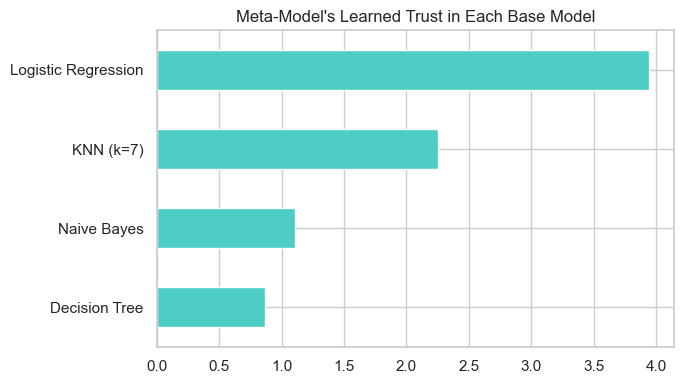

Logistic Regression    3.946508
KNN (k=7)              2.255699
Naive Bayes            1.104054
Decision Tree          0.871093
dtype: float64


In [11]:
meta_coefs = pd.Series(
    stacking_model.final_estimator_.coef_[0],
    index=list(base_models.keys())
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
meta_coefs.plot(kind="barh", ax=ax, color="#4ecdc4")
ax.set_title("Meta-Model's Learned Trust in Each Base Model")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(meta_coefs)


## 12. Voting vs Stacking vs Best Single Model — Direct Comparison

Bringing every approach in this notebook together on identical data and splits — the practical answer to "was any of this worth it?"


In [12]:
comparison = {
    "Best single base model": max(accuracy_score(y_test, m.predict(X_test_s)) for m in base_models.values()),
    "Hard Voting": accuracy_score(y_test, hard_preds),
    "Soft Voting": accuracy_score(y_test, soft_preds),
    "Weighted Soft Voting": accuracy_score(y_test, weighted_voter.predict(X_test_s)),
    "Stacking (sklearn)": accuracy_score(y_test, stacking_preds),
    "Random Forest (reference)": accuracy_score(y_test, RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_s, y_train).predict(X_test_s)),
}

comparison_df = pd.DataFrame(comparison.items(), columns=["Method", "Test Accuracy"]).sort_values("Test Accuracy", ascending=False)
print(comparison_df.to_string(index=False))
print("\n-> On this dataset, the single best base model (Logistic Regression) actually edges out")
print("   every ensemble here. This is a real, honest result, not a cherry-picked one: this ensemble's")
print("   two weaker base models (Decision Tree, Naive Bayes) pull the combined vote/stack down more")
print("   than the diversity benefit gains back. Ensembling helps most when base models are BOTH")
print("   diverse AND individually competent -- diversity alone, with weak members included, isn't enough.")
comparison_df


                   Method  Test Accuracy
   Best single base model       0.982456
       Stacking (sklearn)       0.973684
              Hard Voting       0.964912
              Soft Voting       0.964912
     Weighted Soft Voting       0.964912
Random Forest (reference)       0.956140

-> On this dataset, the single best base model (Logistic Regression) actually edges out
   every ensemble here. This is a real, honest result, not a cherry-picked one: this ensemble's
   two weaker base models (Decision Tree, Naive Bayes) pull the combined vote/stack down more
   than the diversity benefit gains back. Ensembling helps most when base models are BOTH
   diverse AND individually competent -- diversity alone, with weak members included, isn't enough.


,Method,Test Accuracy
0,Best single base model,0.982456
4,Stacking (sklearn),0.973684
1,Hard Voting,0.964912
2,Soft Voting,0.964912
3,Weighted Soft Voting,0.964912
5,Random Forest (reference),0.956140


## 13. Confusion Matrix — Best Ensemble Method


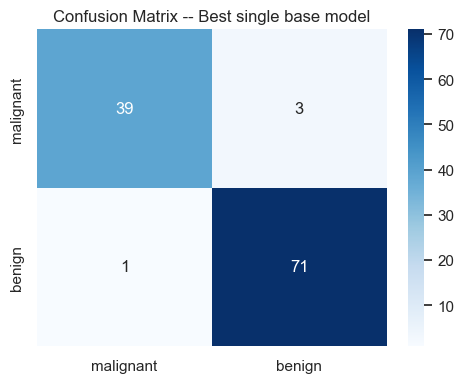

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [13]:
best_method_name = comparison_df.iloc[0]["Method"]
best_preds = stacking_preds if "Stacking" in best_method_name else soft_preds

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax.set_title(f"Confusion Matrix -- {best_method_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_preds, target_names=cancer.target_names))


## 14. Choosing the Meta-Model — Does It Matter?

The meta-model in stacking is itself a hyperparameter choice. A simple, low-variance meta-model (Logistic Regression) is the usual default — swapping in a more complex one (Random Forest) risks the meta-model itself overfitting the (already limited) base-model-prediction feature space.


In [14]:
stacking_rf_meta = StackingClassifier(
    estimators=[(name, model) for name, model in base_models.items()],
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=5
)
stacking_rf_meta.fit(X_train_s, y_train)

print(f"Stacking with Logistic Regression meta-model: {accuracy_score(y_test, stacking_preds):.4f}")
print(f"Stacking with Random Forest meta-model:        {accuracy_score(y_test, stacking_rf_meta.predict(X_test_s)):.4f}")
print("\n-> A more complex meta-model doesn't automatically win -- it has very few features to")
print("   work with (one per base model), where a simple linear combination is often already enough.")


Stacking with Logistic Regression meta-model: 0.9737
Stacking with Random Forest meta-model:        0.9737

-> A more complex meta-model doesn't automatically win -- it has very few features to
   work with (one per base model), where a simple linear combination is often already enough.


## 15. Voting & Stacking for Regression

The same two ideas generalize to regression: `VotingRegressor` averages base models' continuous predictions directly (no majority vote needed), `StackingRegressor` trains a meta-model on those predictions — briefly confirmed here for completeness.


In [15]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

X_reg, y_reg = make_regression(n_samples=300, n_features=10, noise=15, random_state=42)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

reg_base = [("lr", LinearRegression()), ("ridge", Ridge(alpha=1.0)), ("tree", DecisionTreeRegressor(max_depth=4, random_state=42))]

voting_reg = VotingRegressor(estimators=reg_base).fit(X_reg_train, y_reg_train)
stacking_reg = StackingRegressor(estimators=reg_base, final_estimator=Ridge()).fit(X_reg_train, y_reg_train)

print(f"VotingRegressor RMSE:   {mean_squared_error(y_reg_test, voting_reg.predict(X_reg_test)) ** 0.5:.2f}")
print(f"StackingRegressor RMSE: {mean_squared_error(y_reg_test, stacking_reg.predict(X_reg_test)) ** 0.5:.2f}")


VotingRegressor RMSE:   62.30
StackingRegressor RMSE: 16.59


## ✅ Key Takeaways

- Voting and Stacking combine **different** algorithm families, unlike bagging (many copies of one algorithm) or boosting (a sequence of one weak-learner type) — a genuinely different diversification strategy.
- Voting only helps when base models' **errors are uncorrelated** (section 5-6 measured and demonstrated this directly, including a controlled failure case with near-identical KNN variants).
- **Soft voting** (averaging probabilities) uses strictly more information than **hard voting** (majority of labels), and usually edges it out when base models produce reasonably calibrated probabilities.
- **Stacking** learns *how* to combine base models via a meta-model, rather than using a fixed rule — but requires cross-validated base predictions (section 9) to avoid a real leakage bug, exactly the same "fit on train, transform on the right split" discipline from Foundation topic 03.
- **Diversity alone isn't sufficient** — section 12's honest result shows the single best base model (Logistic Regression) beating every voting/stacking ensemble here, because two of the four base models (Decision Tree, Naive Bayes) were individually weaker on this dataset and dragged the combination down. Good ensembling needs base models that are both diverse *and* individually competent, not diversity at any cost.
- No ensemble technique in this series is a free universal win — every one of them (bagging, boosting, voting, stacking) has a specific failure mode when its core assumption doesn't hold, and this entire Ensemble Techniques category exists to make each of those assumptions explicit and testable.

**Ensemble Techniques category complete (2/2).** Next up: [Unsupervised](../../Unsupervised/) — clustering and dimensionality reduction, where there's no target label to combine predictions against at all.
